# Bank Marketing Campaign Prediction using Machine Learning

This python file provides a machine learning project using the Bank Marketing dataset (bank-additional-full.csv). It covers EDA, preprocessing, scaling, encoding, imbalance handling(class weight), correlation analysis, model building, evaluation, hyperparameter tuning, ROC analysis, threshold tuning, SHAP explainability, feature importance and model selection.

# Problem Statement

The objective is to predict whether a customer will subscribe to a term deposit (y) based on demographic, economic, and campaign-related attributes.



*   Type: Binary classification
*   Target variable: y (yes / no)

*   Business goal: Improve campaign efficiency and reduce marketing costs









#Import library

In [1]:
!pip uninstall xgboost -y
!pip install xgboost==1.7.6

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 6.7 MB/s eta 0:00:00


In [2]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.4.2

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 49.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import *

import joblib

In [4]:
# Load
df = pd.read_csv("bank-additional-full.csv", sep = ";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
# Dataset overview

print("Shape:", df.shape)

display(df.head())

df.info()

df.describe() # Statistical summary of numerical column

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


#Data Cleaning and Preprocessing



In [6]:
# Check missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [7]:
# Check duplicates
df.duplicated().sum()

np.int64(12)

In [8]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [9]:
# Remove duplicates
df = df.drop_duplicates()

In [10]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [11]:
df.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [12]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [13]:
df['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', 'unknown', 'university.degree',
       'illiterate'], dtype=object)

Normalize the education - replace '.' with '_'

In [14]:
df['education'] = df['education'].astype('str').str.replace('.','_', regex = False)

Replace 'unknown' with NaN for categerical columns

In [15]:
cat_col = df.select_dtypes(include = 'object').columns.tolist()
for c in cat_col:
  df[c] = df[c].replace('unknown', np.nan)

In [16]:
df.isnull().sum()

,0
age,0
job,330
marital,80
education,1730
default,8596
housing,990
loan,990
contact,0
month,0
day_of_week,0


Impute the missing values for categorical columns with mode

In [17]:
for c in cat_col:
  df[c] = df[c].fillna(df[c].mode()[0])

In [18]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [19]:
df['age'].unique()

array([56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 54, 46, 50, 39, 30, 55,
       49, 34, 52, 58, 32, 38, 44, 42, 60, 53, 47, 51, 48, 33, 31, 43, 36,
       28, 27, 26, 22, 23, 20, 21, 61, 19, 18, 70, 66, 76, 67, 73, 88, 95,
       77, 68, 75, 63, 80, 62, 65, 72, 82, 64, 71, 69, 78, 85, 79, 83, 81,
       74, 17, 87, 91, 86, 98, 94, 84, 92, 89])

In [20]:
df['age'].min(), df['age'].max()

(17, 98)

Convert target(y) into binary

In [21]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [22]:
df['y'] = df['y'].replace({'yes':1, 'no':0})

In [23]:
# Numeric columns
num_col = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
num_col

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

Outliers

In [24]:
#outlier detection via z-score
from scipy import stats
z = np.abs(stats.zscore(df['age']))
outliers = np.where(z > 3)[0]
print(outliers)

[27749 27772 27792 27794 27797 27800 27802 27803 27804 27805 27806 27807
 27808 27809 27810 27818 27843 27867 27922 27942 27943 27955 28212 28213
 28304 28448 29254 29489 29616 29673 29964 29968 29972 29981 29991 29995
 29997 30063 30069 30070 30094 30101 30124 30162 30205 30216 30232 30325
 30421 30451 30580 35823 35846 35868 35963 36173 36275 36301 36373 36374
 36806 36987 37125 37126 37175 37179 37181 37182 37184 37195 37196 37202
 37208 37224 37226 37228 37246 37249 37330 37344 37392 37443 37444 37461
 37468 37482 37494 37498 37501 37514 37521 37586 37590 37591 37593 37624
 37664 37668 37679 37681 37704 37724 37725 37732 37745 37758 37764 37773
 37807 37808 37809 37850 37857 37859 37862 37894 37909 37935 37940 37941
 37943 37988 37994 38008 38009 38011 38021 38022 38034 38041 38043 38054
 38125 38155 38167 38168 38173 38180 38181 38182 38184 38195 38218 38230
 38235 38241 38249 38268 38276 38302 38304 38310 38314 38398 38403 38440
 38443 38459 38474 38493 38505 38506 38524 38536 38

In [25]:
# After cleaning the data store under the another variable name
Portuguese_bank = df.copy()

#EDA - Exploratory Data Analysis

Data Visualization

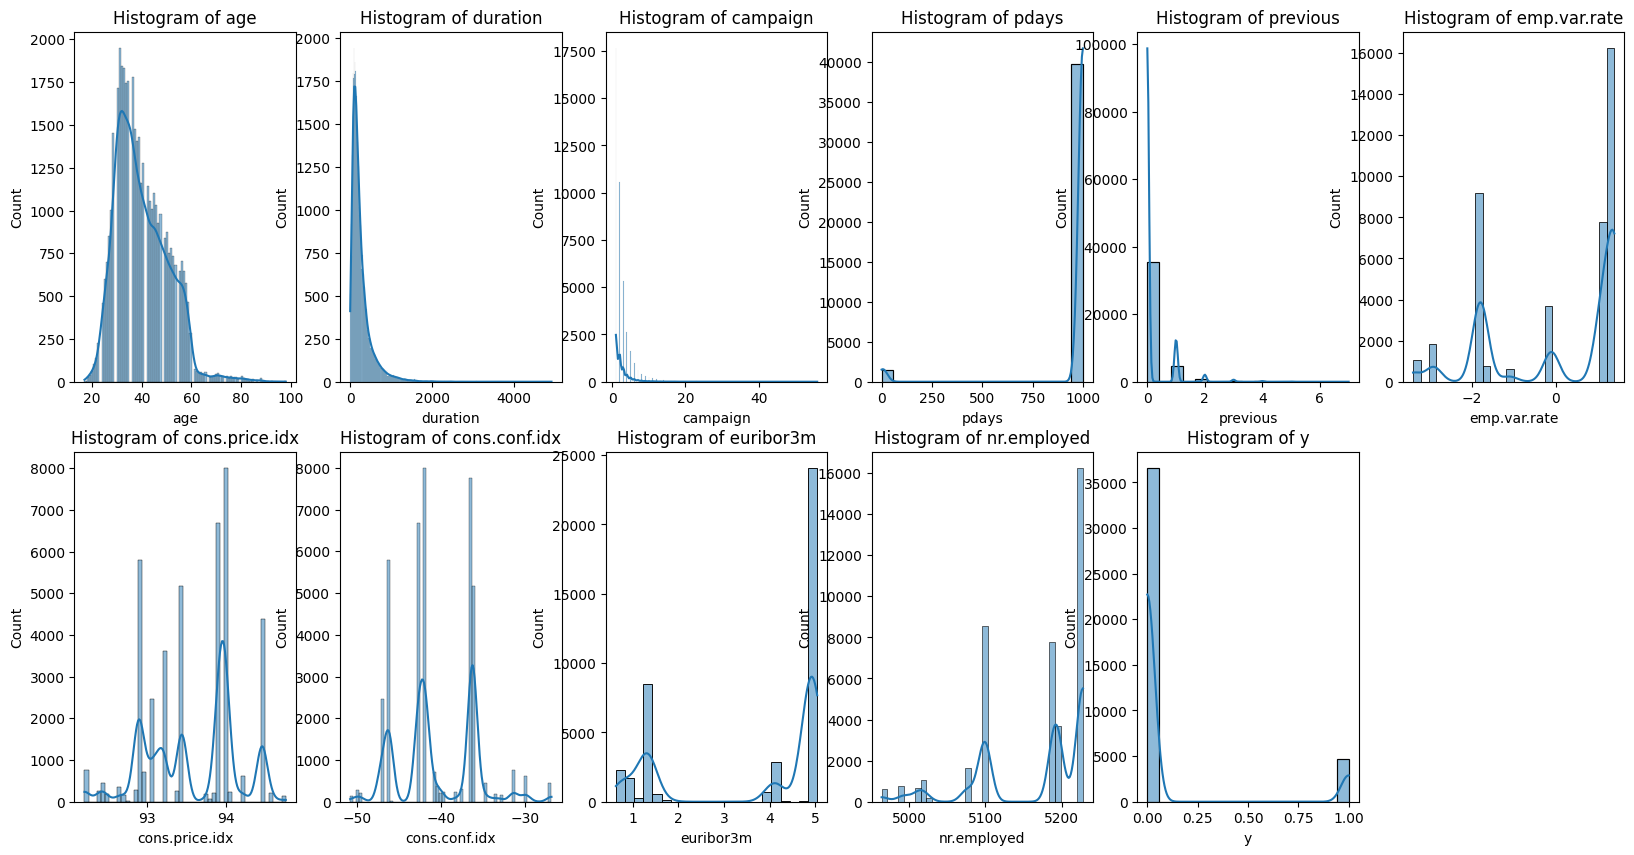

In [26]:
plt.figure(figsize = (20, 10))
pos = 1
for col_name in df.select_dtypes(include = ['int64', 'float64']):
  plt.subplot(2, 6, pos)
  sns.histplot(data = df, x = col_name, kde = True)
  plt.title(f"Histogram of {col_name}")
  pos += 1
plt.show()

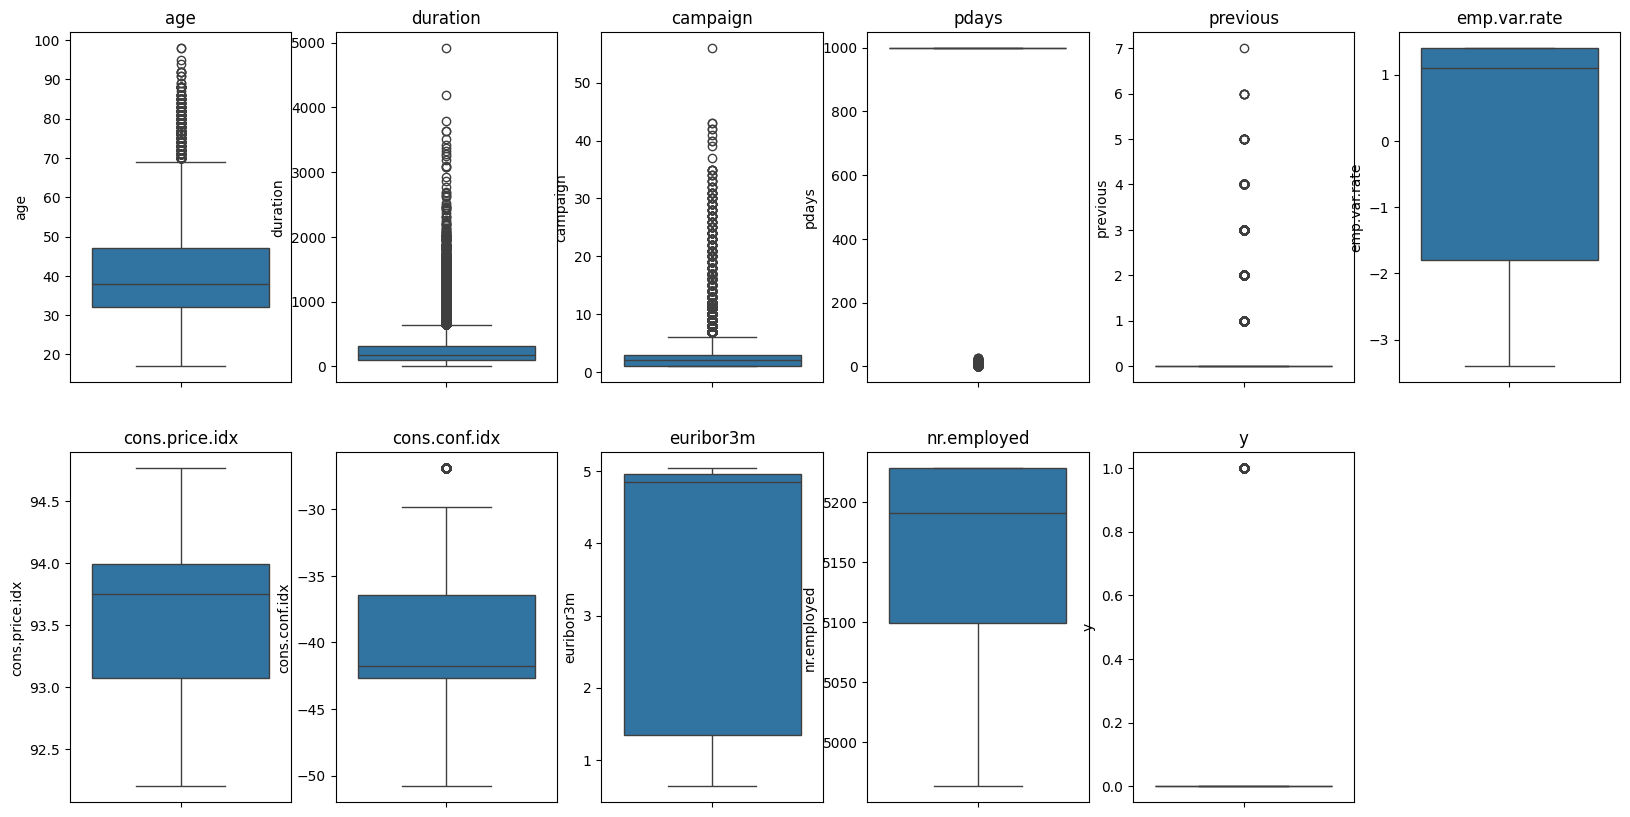

In [27]:
#Box plot - Detect outlier via visualization
plt.figure(figsize = (20, 10))
pos = 1
for col_name in num_col:
  plt.subplot(2, 6, pos)
  sns.boxplot(df[col_name])
  plt.title(col_name)
  pos += 1
plt.show()

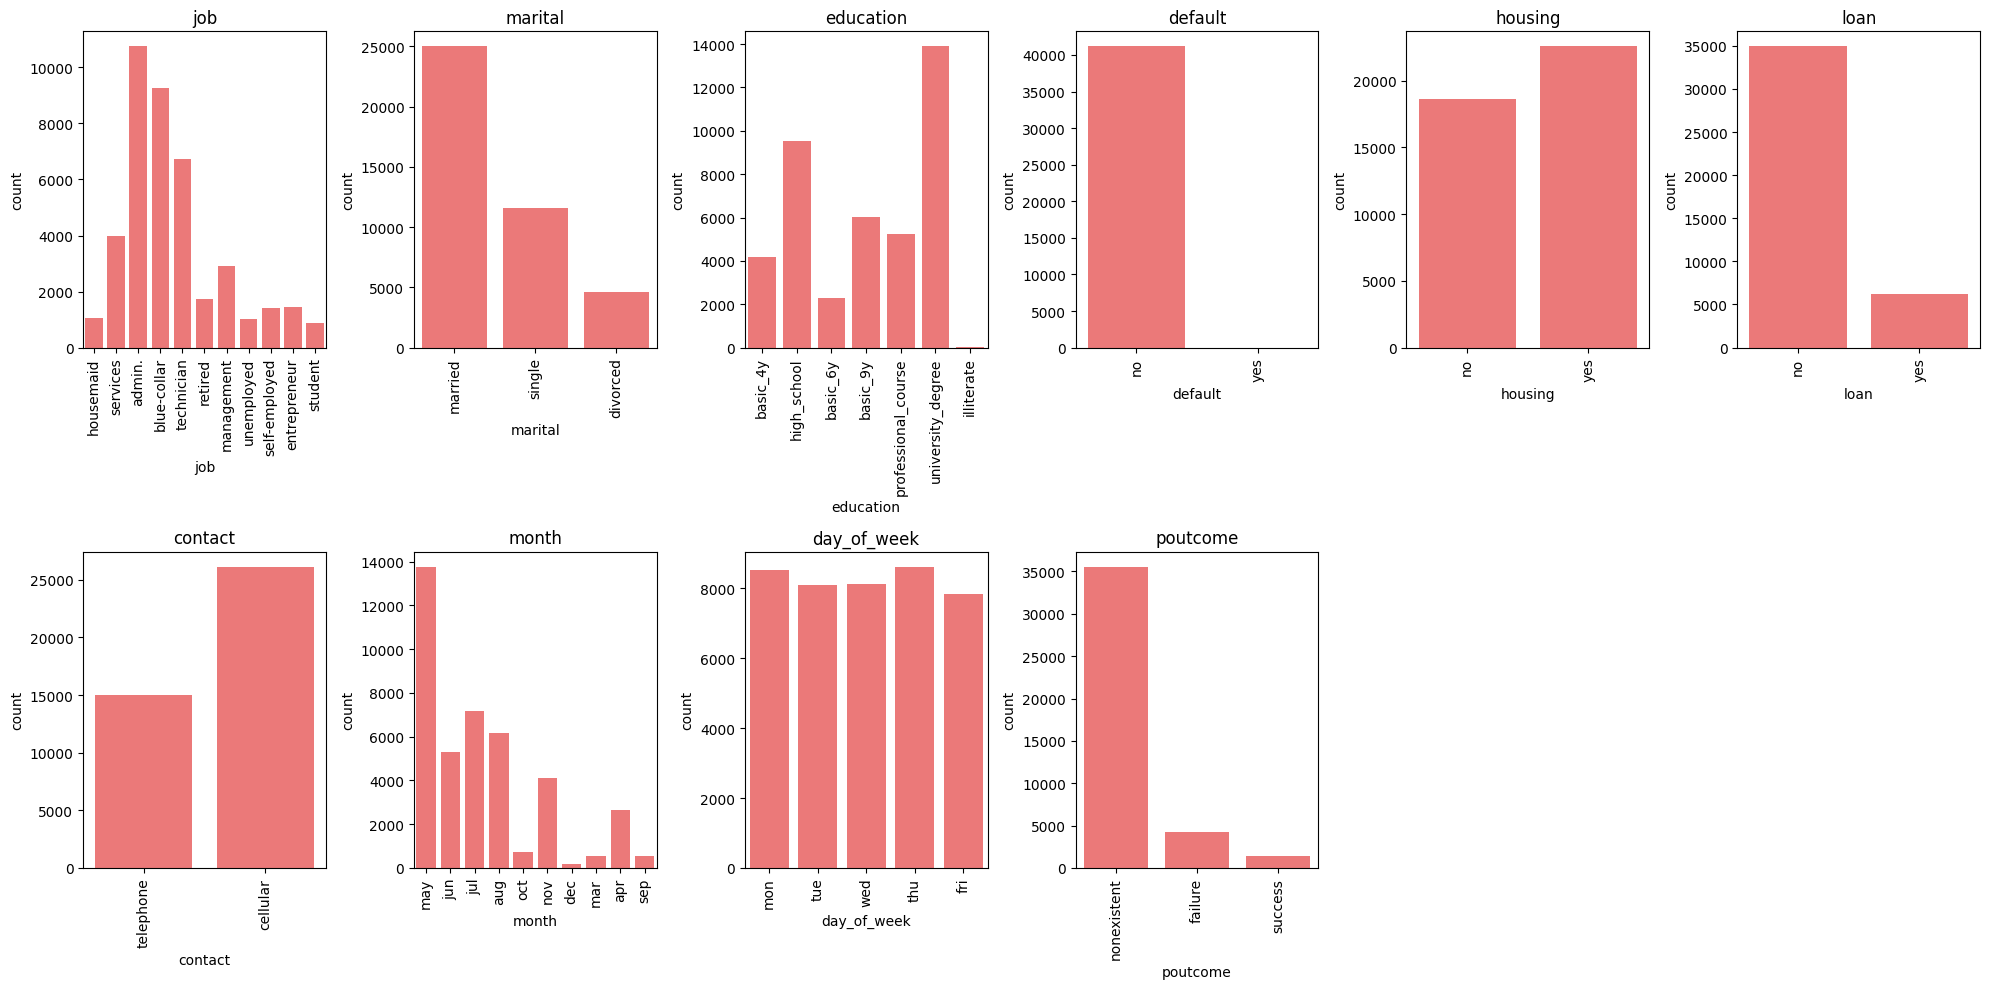

In [28]:
# Count plot for categerical columns
plt.figure(figsize = (20, 10))
pos = 1
for col_name in df.select_dtypes(include = 'object').columns:
  plt.subplot(2, 6, pos)
  sns.countplot(x = df[col_name], palette =['red'], alpha = 0.6)
  plt.title(col_name)
  plt.xticks(rotation = 90)
  pos += 1
plt.tight_layout()
plt.show()

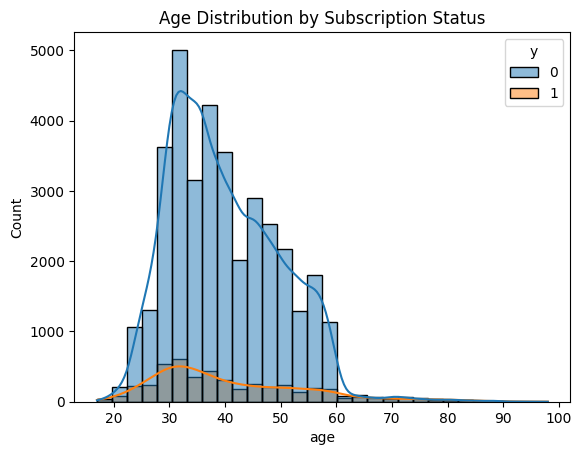

In [29]:
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True)
plt.title('Age Distribution by Subscription Status')
plt.show()

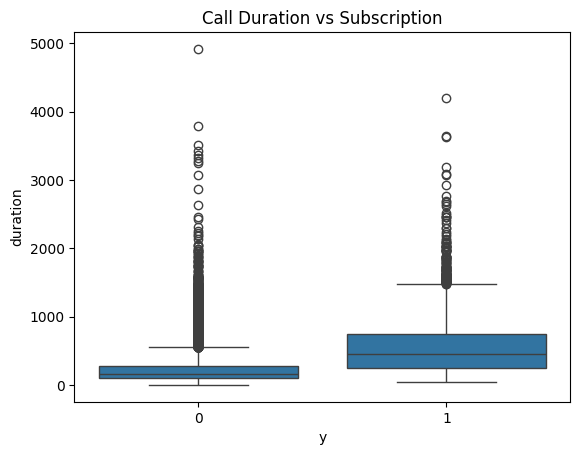

In [30]:
sns.boxplot(x='y', y='duration', data=df)
plt.title('Call Duration vs Subscription')
plt.show()

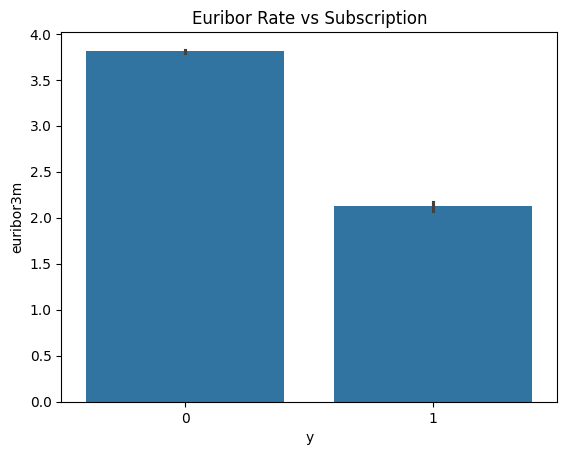

In [31]:
sns.barplot(x='y', y='euribor3m', data=df)
plt.title('Euribor Rate vs Subscription')
plt.show()

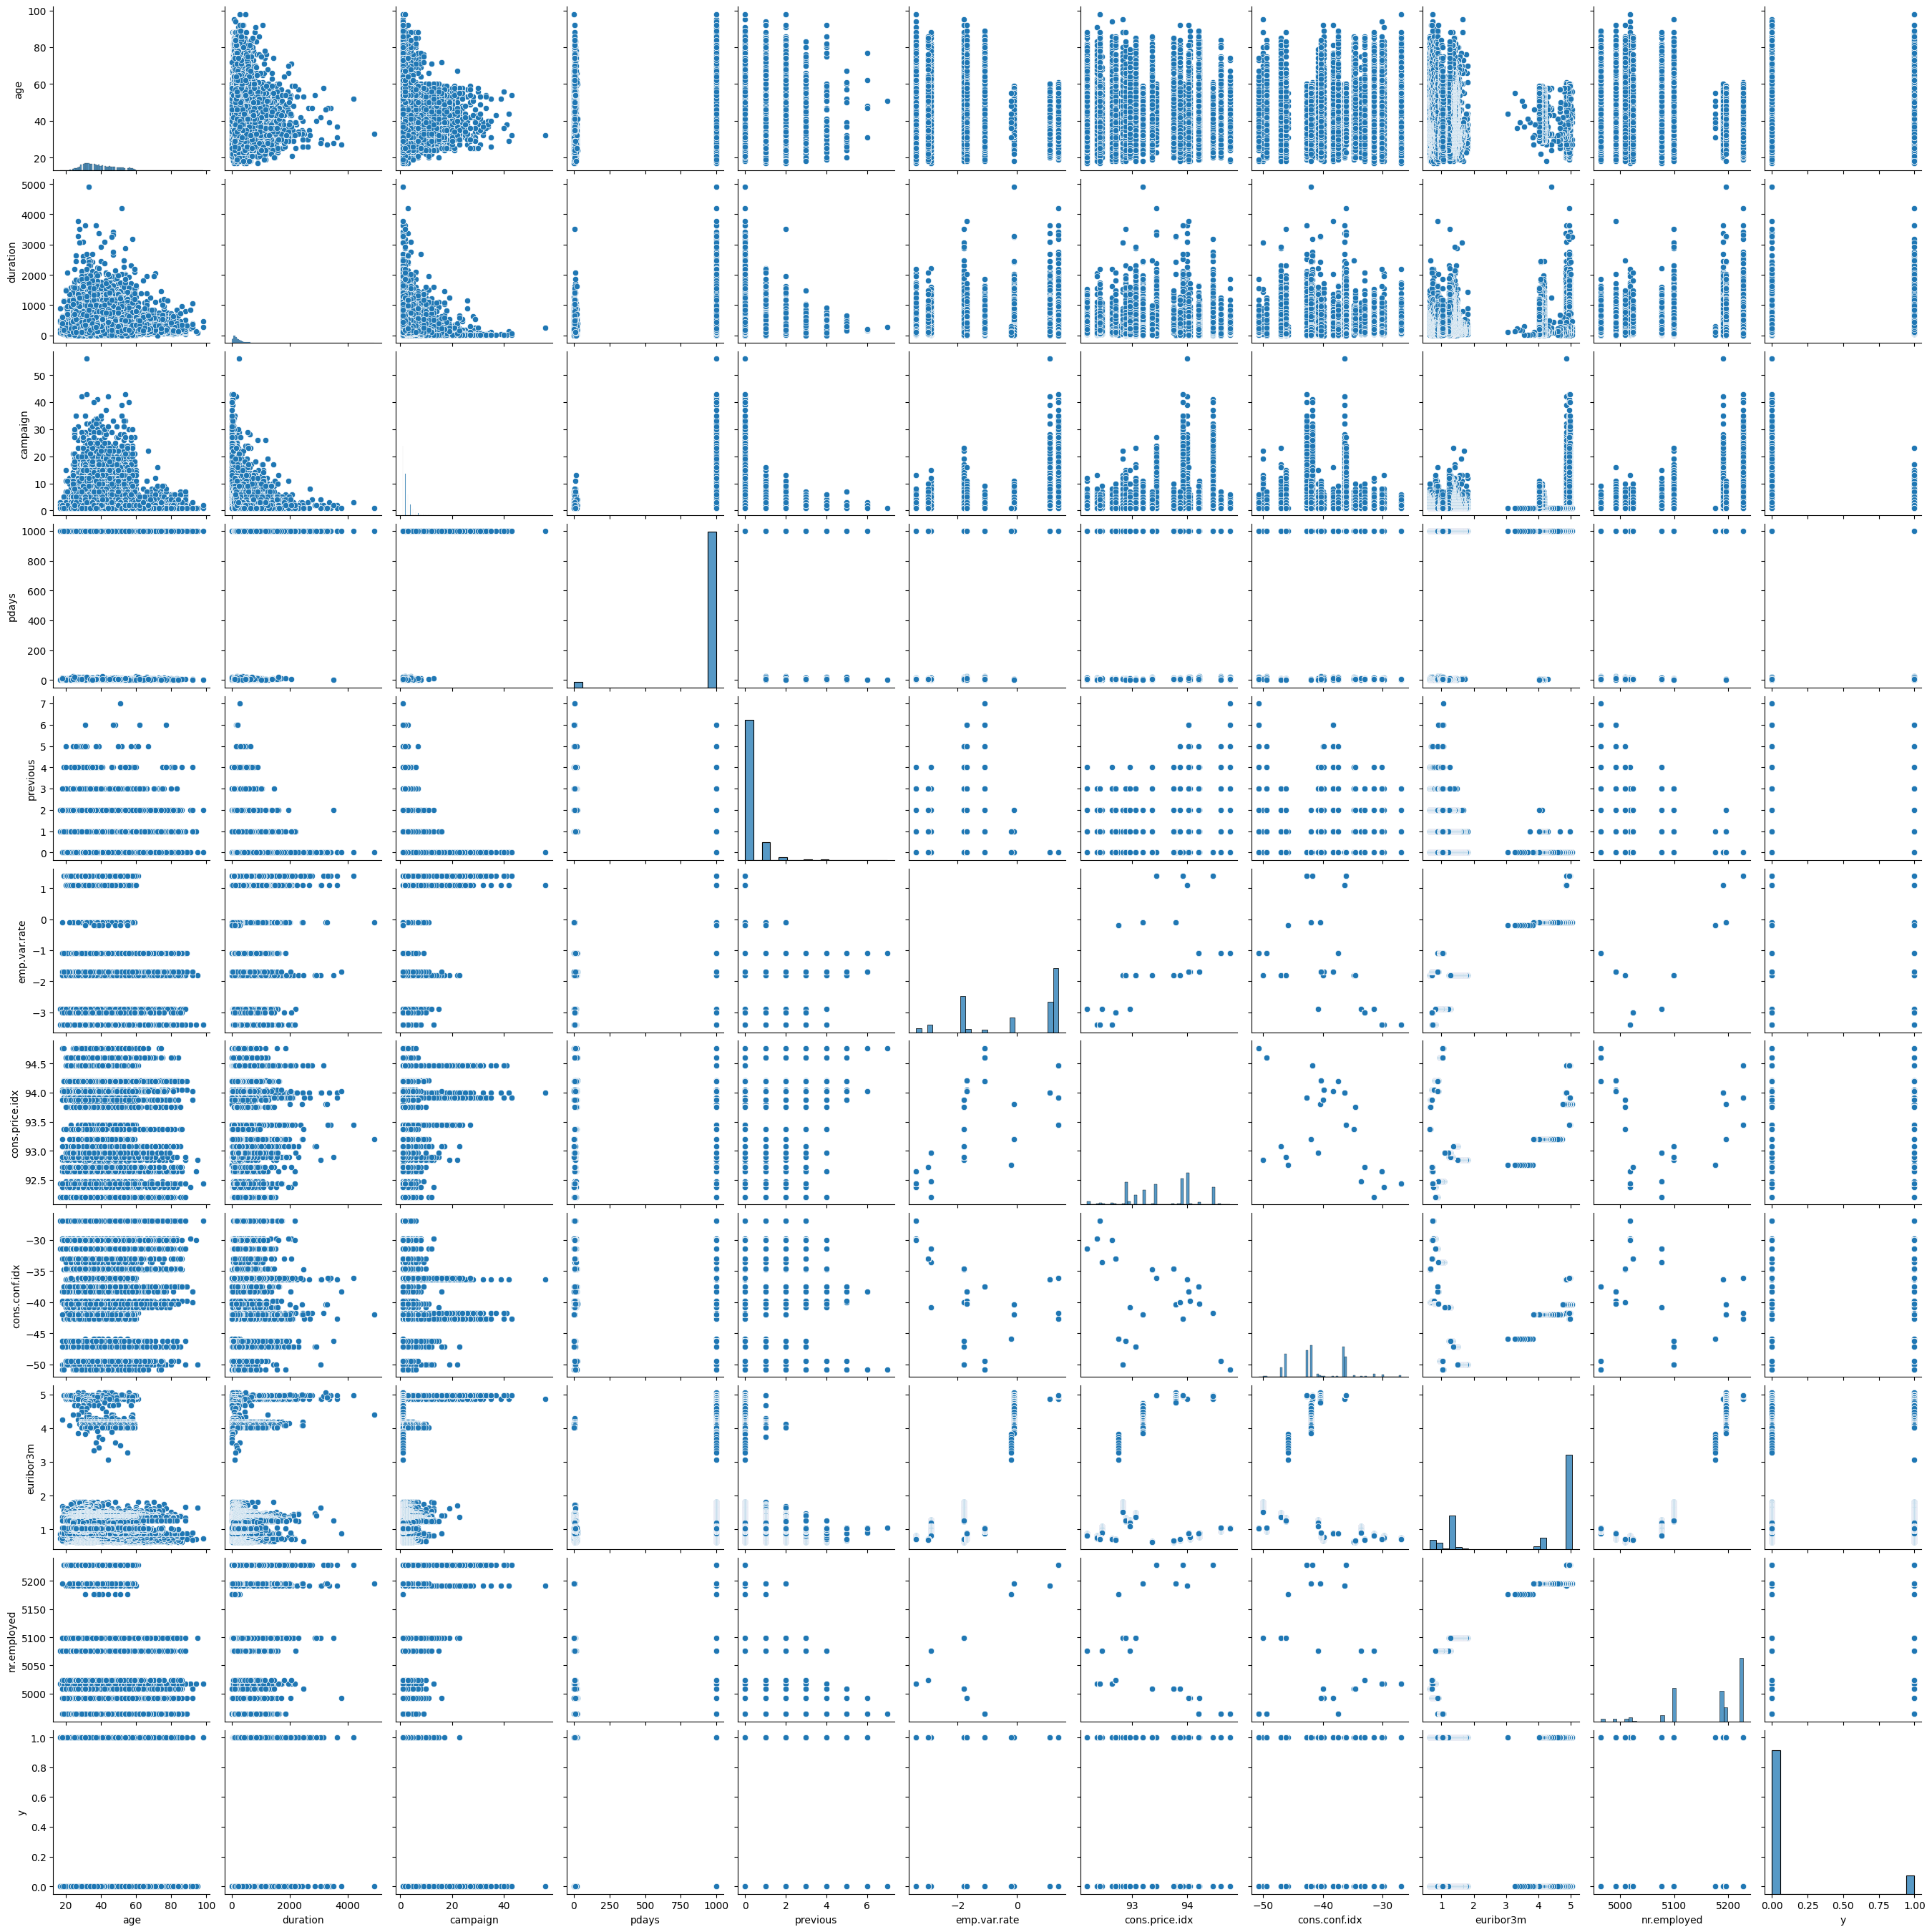

In [32]:
# Pair plot for data set
sns.pairplot(df)

Dataset is imbalanced more 'no' than 'yes'

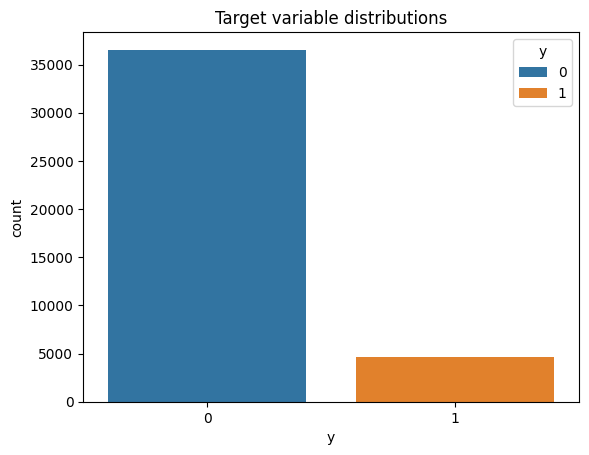

In [33]:
#check imbalance
sns.countplot(x ='y', data = df, hue = 'y')
plt.title('Target variable distributions')
plt.show()

*   **Class Imbalance:** The dataset shows class imbalance where the number of customers who did not subscribe to the term deposit is significantly higher than those who subscribed. This imbalance can bias the model toward predicting the majority class.
To address this issue, the class_weight parameter was used in classification algorithms. This assigns higher penalty to misclassification of the minority class (customers who subscribed), helping the model learn meaningful patterns from both classes.

#Feature Engineering

Creating the new features

In [34]:
#Age group - Binned feature
df['age_group'] = pd.cut(df['age'], bins = [0, 20, 40, 60, 80, 100], labels = ['0-20','21-40','41-60','61-80','81-100'])

In [35]:
#Campaign log
df['campaign_log'] = np.log1p(df['campaign'])

In [36]:
df['previous'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

In [37]:
#Binary flag for previous contact
df['had_prev'] = (df['previous']>0).astype('int')

In [38]:
#Interaction features
df['camp_prev_interaction'] = df['campaign'] * df['previous']

In [39]:
df['poutcome'].value_counts()

,count
poutcome,
nonexistent,35551
failure,4252
success,1373


In [40]:
#Drop 'duration' column for leak target
df = df.drop('duration', axis = 1)

In [41]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,age_group,campaign_log,had_prev,camp_prev_interaction
0,56,housemaid,married,basic_4y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,41-60,0.693147,0,0
1,57,services,married,high_school,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,41-60,0.693147,0,0
2,37,services,married,high_school,no,yes,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,21-40,0.693147,0,0
3,40,admin.,married,basic_6y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,21-40,0.693147,0,0
4,56,services,married,high_school,no,no,yes,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,41-60,0.693147,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional_course,no,yes,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,1,61-80,0.693147,0,0
41184,46,blue-collar,married,professional_course,no,no,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,0,41-60,0.693147,0,0
41185,56,retired,married,university_degree,no,yes,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,0,41-60,1.098612,0,0
41186,44,technician,married,professional_course,no,no,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,1,41-60,0.693147,0,0


In [42]:
#Featured engineered columns sample
df[['age','age_group','campaign','campaign_log','previous','had_prev','camp_prev_interaction']].head()

,age,age_group,campaign,campaign_log,previous,had_prev,camp_prev_interaction
0,56,41-60,1,0.693147,0,0,0
1,57,41-60,1,0.693147,0,0,0
2,37,21-40,1,0.693147,0,0,0
3,40,21-40,1,0.693147,0,0,0
4,56,41-60,1,0.693147,0,0,0


#Split features and target

Problem Definition

In [43]:
x = df.drop('y',axis = 1)
y = df['y']

print("Baseline Conversion Rate:", y.mean())

Baseline Conversion Rate: 0.11266271614532737


*   **Benchmark:** Provides a simple benchmark for evaluating model performance; a good model should outperform this.


Preprocessing pipeline

In [44]:
# Identify the Numerical and Categorical features
num_features = x.select_dtypes(include = ['int64','float64']).columns.tolist()
cat_features = x.select_dtypes(include = 'object').columns.tolist()

# Preprocessing pipeline
numeric_transformer = Pipeline([
    ('Scale', StandardScaler())
])

categorical_transformer = Pipeline([
    ('OneHot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

# Combine the pipeline to Preprocess
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('Scale', StandardScaler())]),
                                 ['age', 'campaign', 'pdays', 'previous',
                                  'emp.var.rate', 'cons.price.idx',
                                  'cons.conf.idx', 'euribor3m', 'nr.employed',
                                  'campaign_log', 'had_prev',
                                  'camp_prev_interaction']),
                                ('cat',
                                 Pipeline(steps=[('OneHot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'day_of_week', 'poutcome'])])

Train and Test split the data

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

Check the Target imbalanced

In [46]:
y_train.value_counts(normalize = True)*100

,proportion
y,
0,88.734062
1,11.265938


In [47]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_target = (
    df[numeric_cols]
    .corrwith(df['y'])
    .sort_values(ascending=False)
)

print(corr_target)

y                        1.000000
previous                 0.230202
had_prev                 0.193522
camp_prev_interaction    0.158300
cons.conf.idx            0.054802
age                      0.030381
campaign                -0.066361
campaign_log            -0.071047
cons.price.idx          -0.136134
emp.var.rate            -0.298289
euribor3m               -0.307740
pdays                   -0.324948
nr.employed             -0.354669
dtype: float64


In [48]:
corr = df[numeric_cols].corr()
corr[corr > 0.8]

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,campaign_log,had_prev,camp_prev_interaction
age,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.900622,NaN,NaN
pdays,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.878771,NaN
emp.var.rate,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.972244,0.906949,NaN,NaN,NaN,NaN
cons.price.idx,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons.conf.idx,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
euribor3m,NaN,NaN,NaN,NaN,0.972244,NaN,NaN,1.000000,0.945146,NaN,NaN,NaN,NaN
nr.employed,NaN,NaN,NaN,NaN,0.906949,NaN,NaN,0.945146,1.000000,NaN,NaN,NaN,NaN
y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


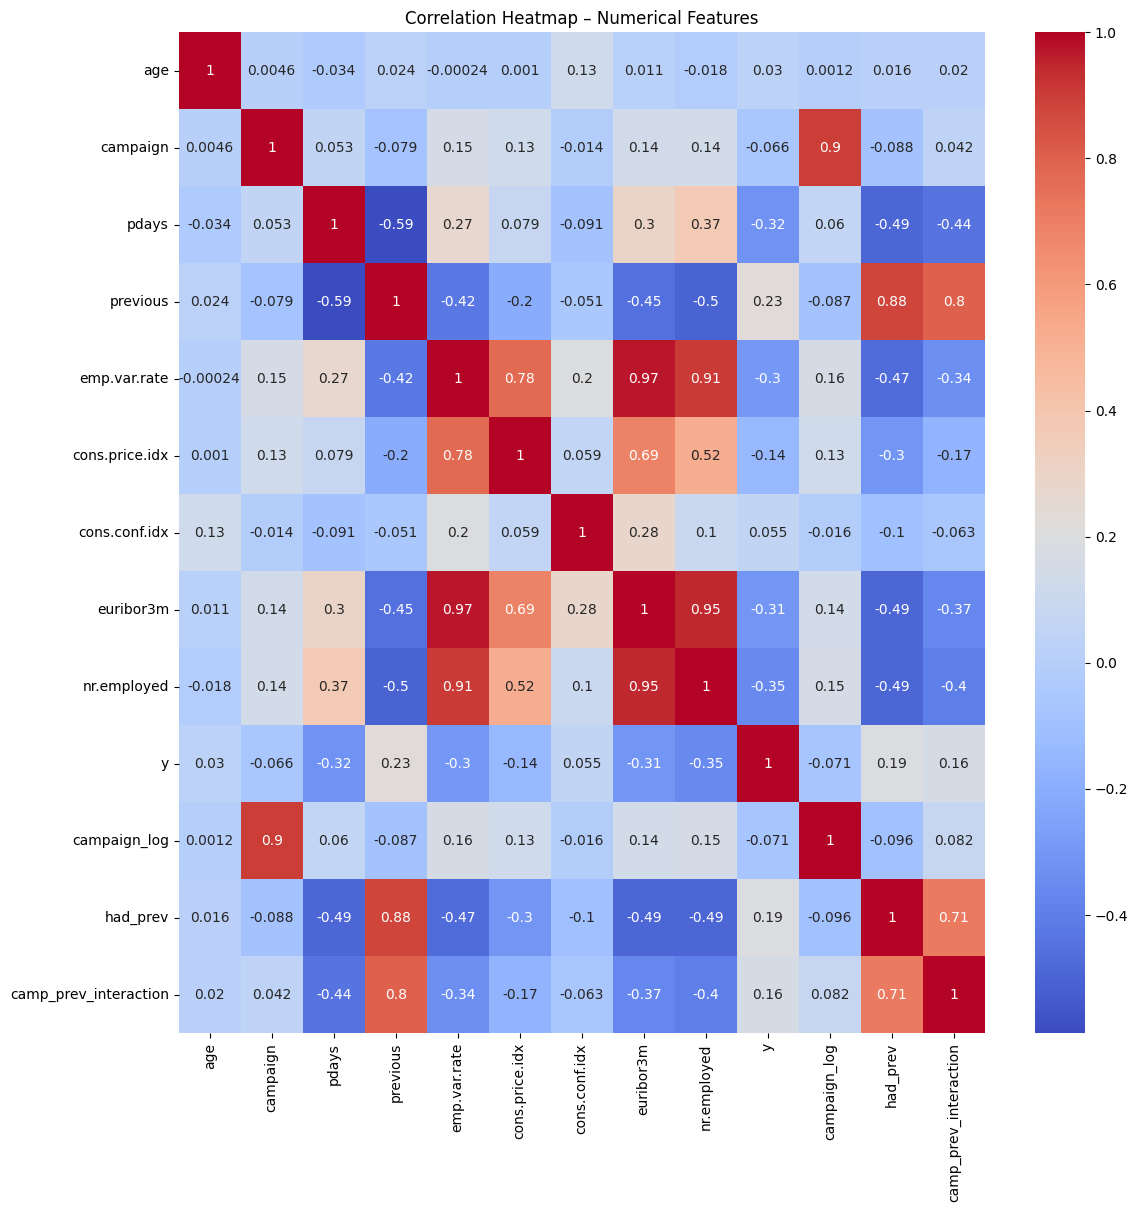

In [49]:
plt.figure(figsize=(13,13))
sns.heatmap(
    df[numeric_cols].corr(),
    cmap='coolwarm',
    annot=True
)
plt.title("Correlation Heatmap – Numerical Features")
plt.show()

# Model Building: Logistic Regression, Decision Tree, Random Forest, XGBoost



In [50]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [51]:
models = {
    "Logistic": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "DecisionTree": DecisionTreeClassifier(max_depth = 6, class_weight = 'balanced', random_state = 42),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators = 200, class_weight = 'balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(
        random_state=42, n_estimators = 300, scale_pos_weight = scale_pos_weight, learning_rate = 0.05,
        max_depth = 5, eval_metric = 'logloss', objective='binary:logistic'
    )
}

I used ROC-AUC because it is threshold-independent and measures ranking ability, which aligns with the campaign objective of prioritizing high-probability customers. Since the optimal business threshold is determined later using cost-benefit analysis, ROC-AUC is appropriate for fair model comparison during cross-validation.

Cross-Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(pipe, x_train, y_train, scoring="roc_auc", cv=cv)
    results[name] = (scores.mean(), scores.std())

for model, (mean, std) in results.items():
    print(f"{model}: ROC-AUC = {mean:.4f} ± {std:.4f}")

* XGBoost is the best model (0.7953 ROC-AUC), offering both the highest accuracy and the most stability (lowest variance). Logistic Regression is a very strong second, performing nearly as well with much less complexity. Both the Decision Tree and Random Forest are underperforming, suggesting the data may favor linear or gradient-boosted patterns over standard bagging.
* We choose xgboost classifier as a best model.


Hyperparameter Tunning For Best Model(XGBoost)

In [ ]:
best_model_name = max(results, key=lambda model_name: results[model_name][0])
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                eval_metric="logloss",
                objective='binary:logistic',
                random_state=42,
            ),
        ),
    ]
)

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__gamma": [0, 1, 5],
    "model__min_child_weight": [1, 3, 5],
    "model__scale_pos_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    scoring="roc_auc",
    cv=cv,
    n_iter=15,
    random_state=42,
    n_jobs=-1,
)

search.fit(x_train, y_train)

best_model = search.best_estimator_

print("Best Parameters:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

Final Evaluation On Test Set

In [ ]:
y_proba = best_model.predict_proba(x_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

print("Best Model:", best_model_name)
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

KS Static (Bank standard)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
ks = max(tpr - fpr)
ks

* The Kolmogorov-Smirnov (KS) statistic measures how well a classification model separates positive and negative classes. It quantifies the maximum difference between their cumulative distribution functions. A higher KS value means the model is better at distinguishing between the two groups. In our case, a KS of 0.53 indicates a strong ability to separate customers who will subscribe from those who will not.

In [ ]:
# Confusion Matrix for Final model(XGBoost)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix-XGBOOST")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

Threshold Optimization

In [ ]:
thresholds = np.linspace(0,1,100)
profits = []

for t in thresholds:
    temp_pred = (y_proba >= t).astype(int)
    tp = ((temp_pred==1) & (y_test==1)).sum()
    fp = ((temp_pred==1) & (y_test==0)).sum()

    revenue = tp * 4000
    cost = (tp + fp) * 20

    profits.append(revenue - cost)

optimal_threshold = thresholds[np.argmax(profits)]
max_profit = max(profits)

print("Optimal Threshold:", optimal_threshold)
print("Maximum Profit:", max_profit)

* That is 3.03% probability cutoff. It is still profitable to call customers with even small predicted probability, because expected revenue outweighs call cost.

In [ ]:
plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit vs Threshold")
plt.show()

Sensitivity Analysis

In [ ]:
cost_range = [10, 20, 30, 40]
revenue_range = [2000, 3000, 4000, 5000]

results = []

for cost in cost_range:
    for revenue in revenue_range:

        tp = ((y_proba >= optimal_threshold) & (y_test == 1)).sum()
        fp = ((y_proba >= optimal_threshold) & (y_test == 0)).sum()

        profit = (tp * revenue) - ((tp + fp) * cost)

        results.append({
            "Cost": cost,
            "Revenue": revenue,
            "Profit": profit
        })

sensitivity_df = pd.DataFrame(results)
sensitivity_df

From the Sensitivity Table,
* Profit increases linearly with revenue
* profit decreases as cost increases
* Model is robust across business scenarios

In [ ]:
pivot_table = sensitivity_df.pivot(index="Cost", columns="Revenue", values="Profit")

plt.figure()
plt.imshow(pivot_table)
plt.colorbar()
plt.xticks(range(len(revenue_range)), revenue_range)
plt.yticks(range(len(cost_range)), cost_range)
plt.xlabel("Revenue per Conversion")
plt.ylabel("Cost per Call")
plt.title("Profit Sensitivity Analysis")
plt.show()

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

baseline = y_test.mean()

plt.figure()
plt.plot(recall, precision)
plt.axhline(y=baseline, linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.3f})")
plt.show()

Lift & Gain Analysis - It evaluates the efficiency of our model in identifying positive cases (customers who subscribe) compared to random targeting.

In [ ]:
df_eval = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba
}).sort_values("y_proba", ascending=False)

df_eval["decile"] = pd.qcut(df_eval.index, 10, labels=False)

gain_table = df_eval.groupby("decile").agg(
    positives=("y_true", "sum"),
    total=("y_true", "count")
)

gain_table["cum_positives"] = gain_table["positives"].cumsum()
gain_table["gain"] = gain_table["cum_positives"] / gain_table["positives"].sum()
gain_table["lift"] = gain_table["gain"] / ((gain_table.index + 1) / 10)

gain_table

* Gain Chart: Shows the cumulative percentage of target customers identified by the model when targeting a certain percentage of the total customer base, ordered by their predicted probability. It helps to see how many of the 'yes' responses you can capture by contacting a specific top percentile of customers.

In [ ]:
plt.figure()
plt.plot(np.arange(1, 11)/10, gain_table["gain"], marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Proportion of Customers Targeted")
plt.ylabel("Cumulative Gain")
plt.title("Cumulative Gain Chart")
plt.show()

* Lift Chart: Indicates how much more effective your model is at finding positive responses compared to if you randomly contacted customers. A lift of 2 at the top 10% means you are twice as likely to find a subscriber by using your model to target the top 10% most probable customers, than if you chose 10% of customers randomly.

In [ ]:
plt.figure()
plt.plot(np.arange(1, 11)/10, gain_table["lift"], marker='o')
plt.xlabel("Proportion of Customers Targeted")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.show()

Calibration Analysis

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Predicted probabilities
y_proba = best_model.predict_proba(x_test)[:, 1]

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.show()

print("Brier Score:", brier_score_loss(y_test, y_proba))

* The Calibration Curve visually shows this relationship, with a perfectly calibrated model following the diagonal line.
* The Brier Score quantifies this calibration, with lower scores indicating better calibration. Your model's Brier Score of 0.113 indicates a good level of calibration, which is positive for marketing models as it means the probabilities can be trusted for decision-making.

SHAP explainabilitiy - SHapley Additive exPlainations

In [ ]:
import shap

# Extract transformed data
x_test_transformed = best_model.named_steps["preprocessor"].transform(x_test)

explainer = shap.TreeExplainer(best_model.named_steps["model"])
shap_values = explainer.shap_values(x_test_transformed)

shap.summary_plot(shap_values, x_test_transformed)

* The SHAP summary plot visualizes feature importance and their impact on model predictions. It ranks features by influence (y-axis), shows how each feature's value affects the prediction (x-axis, SHAP value), and uses color to indicate the original feature value (red for high, blue for low). Each dot represents a data instance, allowing you to see how specific feature values drive predictions up or down.

ROI Simulation

Baseline(Random)

In [ ]:
revenue_per_conversion = 4000 # Example value, adjust as needed
cost_per_call = 20 # Example value, adjust as needed

# Define Budget(Top 30%)
top_fraction = 0.30
calls = int(top_fraction * len(df_eval))

# Baseline(Random selection with same budget)
baseline_rate = y.mean()

baseline_conversions = calls * baseline_rate
baseline_revenue = baseline_conversions * revenue_per_conversion
baseline_cost = calls * cost_per_call

baseline_profit = baseline_revenue - baseline_cost
print("Baseline profit: ",baseline_profit)

# Model Strategy(Top 30%)
top_30 = df_eval.head(int(0.3 * len(df_eval)))
model_rate = top_30["y_true"].mean()

model_calls = 3000
model_conversions = model_calls * model_rate
model_revenue = model_conversions * revenue_per_conversion
model_cost = model_calls * cost_per_call

model_profit = model_revenue - model_cost
print("Model Profit: ",model_profit)

* The ROI simulation compares the profit generated by the model's targeting strategy versus a random selection strategy, given the same outreach budget. The results show that the model-based targeting leads to a significantly higher profit (approximately 3.29 million) compared to random selection (approximately 1.06 million), effectively tripling the campaign profitability.

Confidence Interval for ROC-Auc

In [ ]:
from sklearn.utils import resample
n_bootstraps = 1000
bootstrapped_scores = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)))

    if len(np.unique(y_test.iloc[indices])) < 2:
        continue

    score = roc_auc_score(
        y_test.iloc[indices],
        y_proba[indices]
    )
    bootstrapped_scores.append(score)

sorted_scores = np.sort(bootstrapped_scores)

lower = sorted_scores[int(0.025 * len(sorted_scores))]
upper = sorted_scores[int(0.975 * len(sorted_scores))]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("95% Confidence Interval:", (lower, upper))

* The ROC-AUC confidence interval indicates the reliability and stability of the model's performance. A narrow interval and both upper and lower bounds significantly above 0.75 suggest that the model is statistically robust and consistently performs well in distinguishing between classes.

Save Model

In [ ]:
features = best_model.named_steps["preprocessor"].get_feature_names_out().tolist()

In [ ]:
metrics = {
"roc":0.81,
"brier":0.113,
"profit":3290000
}

pipeline = {
"model":best_model,
"threshold":optimal_threshold,
"features":features,
"metrics":metrics
}

joblib.dump(pipeline, "bank_pipeline.joblib")

## Predictive System

In [ ]:
# Load Saved Model
loaded_artifact = joblib.load('bank_pipeline.joblib')
model = loaded_artifact['model']

# Optimal threshold from profit optimization
optimal_thresh = loaded_artifact['threshold']

# Select input from dataset
sample_input = x.iloc[:100]
actual_value = y.iloc[:100]

# Predict probability
probability = model.predict_proba(sample_input)[:,1]

# Apply optimal threshold
prediction = (probability >= optimal_thresh).astype(int)

In [ ]:
results = pd.DataFrame({
    "Actual": actual_value.values,
    "Predicted": prediction,
    "Probability": probability
})

print(results.tail(20))

* Due to profit optimization, the optimal classification threshold was found to be 0.03. This indicates that even customers with small subscription probability may still be profitable to contact. However, this may lead to a high number of false positives. Therefore, in practical deployment, additional constraints such as marketing budget or contact limits should be applied.

In [ ]:
if prediction[0] == 1:
    print("Prediction: Client WILL subscribe")
else:
    print("Prediction: Client will NOT subscribe")

print("Actual Value:", actual_value)

In [ ]:
# Select customer record for prediction
customer = x.iloc[[25]]
actual_value = y.iloc[25]

# Predict subscription probability
probability = model.predict_proba(customer)[:,1][0]

# Profit-Based Decision Rule
prediction = 1 if probability >= optimal_threshold else 0

# Marketing decision system
decision = "CONTACT CUSTOMER" if prediction == 1 else "DO NOT CONTACT"


In [ ]:
# Display predictive system
print("----- Bank Marketing Predictive System -----")

print("\nCustomer Index:", 25)
print("Predicted Probability:", round(probability,4))
print("Optimal Threshold:", round(optimal_threshold,4))

print("\nPrediction:", "Will Subscribe" if prediction==1 else "Will NOT Subscribe")
print("Actual Value:", actual_value)

print("\nMarketing Decision:", decision)

# Final Project Summary

## Business Objective

The objective was to build a predictive model to identify customers most likely to subscribe to a term deposit during a marketing campaign.

Baseline conversion rate ≈ ~11%.

**Business goal:**
Improve campaign efficiency by prioritizing high-probability customers, reducing unnecessary calls, and increasing conversions per 10,000 contacts.

## Model Used

Final selected model: XGBoost (after cross-validation comparison and hyperparameter tuning).

Why selected:

* Highest cross-validated ROC-AUC

* Strong PR-AUC (better positive class focus)

* Stable performance across folds

* Good probability ranking for campaign prioritization

## Key Test Metrics

Final model performance on unseen test data:

* ROC-AUC: ~0.81

* PR-AUC: ~0.48

* Precision: ~0.46

* Recall: ~0.61

* F1-score: ~0.53

Interpretation:
The model significantly outperforms baseline random targeting and demonstrates strong ranking ability for identifying potential converters.

## Threshold Optimization

Optimal probability threshold: 0.0303

This threshold was selected by maximizing expected profit.

With:

* Revenue per conversion = ₹4000

* Cost per call = ₹20

Break-even probability = 0.5%

The optimal threshold (3%) is economically justified and profit-maximizing.

## ROI Analysis (Fixed 30% Outreach Budget)
Assumptions:

* Revenue per conversion: ₹4000

* Cost per call: ₹20

* Contacting top 30% customers

Results:

* Random Selection = 1,063,708
* Model-Based Targeting	3,292,227

Business Conclusion:

Under identical outreach budget, model-driven targeting more than triples campaign profitability compared to random selection.

## Sensitivity Analysis

The strategy remains profitable across a wide range of economic assumptions, demonstrating robustness of the model-driven targeting approach.

## Business Integration

The model enables:

* Data-driven customer prioritization

* Reduced wasted calls

* Improved campaign ROI

* Scalable targeting process

## Limitations

* Assumes stable customer behavior over time

* Revenue and cost assumptions may vary

* No macroeconomic or competitor effects modeled

* Requires monitoring for data drift

## Conclusion

Overall, this project demonstrates not only technical proficiency in machine learning for imbalanced classification, but also the ability to translate predictive modeling into quantifiable financial impact and deployment-ready business solutions.

This is a complete, production-oriented marketing analytics framework rather than a purely academic modeling exercise.